In [3]:
# ============================================================
# 1. IMPORTS & SETUP
# ============================================================
import os
import pandas as pd
import numpy as np
from collections import Counter
from itertools import islice
import spacy
import nltk
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('punkt_tab')

nlp = spacy.load("de_core_news_sm")

[nltk_data] Downloading package punkt to /Users/Eva/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/Eva/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
# ============================================================
# 2. TEXTE LADEN
# ============================================================
base = "Texte/"

def load_texts(folder):
    texts = {}
    for file in os.listdir(folder):
        if file.endswith(".txt"):
            with open(os.path.join(folder, file), "r", encoding="utf-8") as f:
                texts[file] = f.read()
    return texts

lebzeit = load_texts(base + "lebzeit/")
posthum = load_texts(base + "posthum/")
brod    = load_texts(base + "brod/")

for label, corpus in [("lebzeit", lebzeit), ("posthum", posthum), ("brod", brod)]:
    total_words = sum(len(nltk.word_tokenize(t, language="german")) for t in corpus.values())
    print(f"{label}: {len(corpus)} Texte, {total_words} Tokens")

lebzeit: 10 Texte, 48151 Tokens
posthum: 16 Texte, 29511 Tokens
brod: 3 Texte, 106312 Tokens


In [5]:
# ============================================================
# 3. CHUNKS MIT 25% OVERLAPPING
# ============================================================
def chunk_text_overlap(text, chunk_size=150, overlap=0.25):
    tokens = nltk.word_tokenize(text, language="german")
    step = int(chunk_size * (1 - overlap))  # 25% overlap = 75% Schrittweite
    chunks = []
    for i in range(0, len(tokens) - chunk_size // 2, step):
        chunk = tokens[i:i + chunk_size]
        if len(chunk) >= chunk_size // 2:
            chunks.append(" ".join(chunk))
    return chunks

# Chunks erstellen - nur lebzeit und posthum
rows = []
for label, corpus in [("lebzeit", lebzeit), ("posthum", posthum)]:
    for filename, text in corpus.items():
        for i, chunk in enumerate(chunk_text_overlap(text)):
            rows.append({"label": label, "source": filename,
                         "chunk_id": i, "text": chunk})

df = pd.DataFrame(rows)
print("Chunks vor Balancing:")
print(df["label"].value_counts())

min_size = df["label"].value_counts().min()
df_balanced = df.groupby("label").sample(min_size, random_state=42).reset_index(drop=True)
print("\nNach Balancing:")
print(df_balanced["label"].value_counts())

Chunks vor Balancing:
label
lebzeit    427
posthum    260
Name: count, dtype: int64

Nach Balancing:
label
lebzeit    260
posthum    260
Name: count, dtype: int64


In [6]:
# ============================================================
# 4. GLOBALE N-GRAMME BESTIMMEN
# ============================================================
all_bigrams = Counter()
all_trigrams = Counter()

for text in df_balanced["text"]:
    tokens = nltk.word_tokenize(text, language="german")
    words = [w.lower() for w in tokens if w.isalpha()]
    all_bigrams.update(zip(words, words[1:]))
    all_trigrams.update(zip(words, words[1:], words[2:]))

top50_bigrams = [bg for bg, _ in all_bigrams.most_common(50)]
top50_trigrams = [tg for tg, _ in all_trigrams.most_common(50)]

print(f"Top Bigram: {top50_bigrams[0]}")
print(f"Top Trigram: {top50_trigrams[0]}")

Top Bigram: ('in', 'der')
Top Trigram: ('sagte', 'der', 'offizier')


In [7]:
# ============================================================
# 5. MERKMALSEXTRAKTION
# ============================================================
function_words = [
    "der", "die", "das", "und", "in", "zu", "den", "ist", "von", "mit",
    "sich", "des", "auf", "für", "an", "er", "es", "nicht", "als", "auch",
    "ich", "ein", "eine", "einen", "einem", "einer", "war", "haben", "werden",
    "aber", "oder", "wenn", "dann", "so", "noch", "nur", "nach", "bei", "wie"
]

def extract_features(text, nlp):
    # NLTK Tokenisierung
    tokens = nltk.word_tokenize(text, language="german")
    words = [w.lower() for w in tokens if w.isalpha()]
    
    # spaCy für POS und Satzgrenzen
    doc = nlp(text)
    sentences = list(doc.sents)
    
    # Oberflächenmerkmale
    avg_word_length = sum(len(w) for w in words) / len(words) if words else 0
    avg_sent_length = len(words) / len(sentences) if sentences else 0
    punct_ratio = sum(1 for t in tokens if t in ".,;:!?") / len(tokens) if tokens else 0
    comma_ratio = sum(1 for t in tokens if t == ",") / len(tokens) if tokens else 0
    ttr = len(set(words)) / len(words) if words else 0

    # Funktionswörter
    fw_counts = Counter(w for w in words if w in function_words)
    fw_ratio = {f"fw_{w}": fw_counts[w] / len(words) for w in function_words}

    # POS-Frequenzen
    pos_counts = Counter(token.pos_ for token in doc if not token.is_space)
    total_tokens = sum(pos_counts.values())
    pos_freq = {f"pos_{pos}": count / total_tokens for pos, count in pos_counts.items()}

    # N-Gramme
    bigram_counts = Counter(zip(words, words[1:]))
    trigram_counts = Counter(zip(words, words[1:], words[2:]))
    top_bigrams = {f"bg_{'_'.join(bg)}": bigram_counts.get(bg, 0) / len(words) for bg in top50_bigrams}
    top_trigrams = {f"tg_{'_'.join(tg)}": trigram_counts.get(tg, 0) / len(words) for tg in top50_trigrams}

    return {
        "avg_word_length": avg_word_length,
        "avg_sent_length": avg_sent_length,
        "punct_ratio": punct_ratio,
        "comma_ratio": comma_ratio,
        "ttr": ttr,
        **fw_ratio,
        **pos_freq,
        **top_bigrams,
        **top_trigrams
    }

feature_list = []
for _, row in df_balanced.iterrows():
    features = extract_features(row["text"], nlp)
    features["label"] = row["label"]
    feature_list.append(features)

df_features = pd.DataFrame(feature_list).fillna(0)

core_cols = [col for col in df_features.columns
             if not col.startswith("bg_")
             and not col.startswith("tg_")
             and col != "label"]

X_core = df_features[core_cols]
X_core_scaled = StandardScaler().fit_transform(X_core)
y = df_features["label"]

print(f"Shape: {df_features.shape}")
print(f"Core features: {len(core_cols)}")
print(df_features.groupby("label")[["avg_sent_length", "punct_ratio", "comma_ratio", "ttr"]].mean())

Shape: (520, 161)
Core features: 60
         avg_sent_length  punct_ratio  comma_ratio       ttr
label                                                       
lebzeit        17.255192     0.135909     0.085216  0.734876
posthum        21.827276     0.134424     0.096987  0.727529


In [8]:
# Brod als Referenz
brod_rows = []
for filename, text in brod.items():
    for i, chunk in enumerate(chunk_text_overlap(text)):
        brod_rows.append({"label": "brod", "source": filename,
                         "chunk_id": i, "text": chunk})

df_brod = pd.DataFrame(brod_rows)

brod_feature_list = []
for _, row in df_brod.iterrows():
    features = extract_features(row["text"], nlp)
    features["label"] = "brod"
    brod_feature_list.append(features)

df_brod_features = pd.DataFrame(brod_feature_list).fillna(0)

print("Brod Referenzwerte:")
print(df_brod_features[["avg_sent_length", "punct_ratio", "comma_ratio", "ttr"]].mean())

Brod Referenzwerte:
avg_sent_length    17.260324
punct_ratio         0.134438
comma_ratio         0.085036
ttr                 0.769585
dtype: float64


In [9]:
# ============================================================
# 6. STATISTISCHE TESTS - lebzeit vs. posthum
# ============================================================
lebzeit_data = df_features[df_features["label"] == "lebzeit"]
posthum_data = df_features[df_features["label"] == "posthum"]

results = []
for col in core_cols:
    _, p_leb = stats.shapiro(lebzeit_data[col])
    _, p_pos = stats.shapiro(posthum_data[col])
    normal = p_leb > 0.05 and p_pos > 0.05

    if normal:
        stat, p = stats.ttest_ind(lebzeit_data[col], posthum_data[col])
        test = "t-test"
    else:
        stat, p = stats.mannwhitneyu(lebzeit_data[col], posthum_data[col])
        test = "mann-whitney"

    pooled_std = ((lebzeit_data[col].std()**2 + posthum_data[col].std()**2) / 2) ** 0.5
    d = (lebzeit_data[col].mean() - posthum_data[col].mean()) / pooled_std if pooled_std > 0 else 0

    results.append({
        "feature": col,
        "test": test,
        "p_value": p,
        "cohens_d": abs(d),
        "signifikant": p < 0.05,
        "lebzeit_mean": lebzeit_data[col].mean(),
        "posthum_mean": posthum_data[col].mean(),
        "brod_mean": df_brod_features[col].mean() if col in df_brod_features.columns else np.nan
    })

df_results = pd.DataFrame(results)
sig = df_results[df_results["signifikant"]].sort_values("cohens_d", ascending=False)
print(f"Signifikante Unterschiede: {len(sig)} von {len(core_cols)}")
print(sig[["feature", "test", "p_value", "cohens_d", "lebzeit_mean", "posthum_mean", "brod_mean"]].to_string())

Signifikante Unterschiede: 34 von 60
            feature          test       p_value  cohens_d  lebzeit_mean  posthum_mean  brod_mean
50          pos_ADV  mann-whitney  9.195664e-14  0.644545      0.114382      0.136551   0.131820
25           fw_ich  mann-whitney  3.116431e-13  0.629876      0.018474      0.032865   0.017429
3       comma_ratio  mann-whitney  1.876303e-09  0.553790      0.085216      0.096987   0.085036
20            fw_er  mann-whitney  8.031530e-14  0.540359      0.016787      0.008280   0.014453
47        pos_PUNCT  mann-whitney  9.790225e-08  0.535071      0.162752      0.143562   0.171514
1   avg_sent_length  mann-whitney  8.349707e-15  0.529084     17.255192     21.827276  17.260324
5            fw_der  mann-whitney  4.083077e-09  0.513743      0.031019      0.022260   0.018809
58        pos_PROPN  mann-whitney  1.094083e-07  0.483325      0.007179      0.003183   0.011493
14           fw_mit  mann-whitney  1.749355e-07  0.453711      0.010322      0.006685   0.

In [10]:
# ============================================================
# 6. STATISTISCHE TESTS - lebzeit vs. posthum UND posthum vs. brod
# ============================================================
lebzeit_data = df_features[df_features["label"] == "lebzeit"]
posthum_data = df_features[df_features["label"] == "posthum"]
brod_data = df_brod_features

results = []
for col in core_cols:
    if col not in brod_data.columns:
        continue
        
    _, p_leb = stats.shapiro(lebzeit_data[col])
    _, p_pos = stats.shapiro(posthum_data[col])
    _, p_bro = stats.shapiro(brod_data[col])

    # lebzeit vs. posthum
    normal_lp = p_leb > 0.05 and p_pos > 0.05
    if normal_lp:
        stat, p_lp = stats.ttest_ind(lebzeit_data[col], posthum_data[col])
        test_lp = "t-test"
    else:
        stat, p_lp = stats.mannwhitneyu(lebzeit_data[col], posthum_data[col])
        test_lp = "mann-whitney"
    pooled_lp = ((lebzeit_data[col].std()**2 + posthum_data[col].std()**2) / 2) ** 0.5
    d_lp = (lebzeit_data[col].mean() - posthum_data[col].mean()) / pooled_lp if pooled_lp > 0 else 0

    # posthum vs. brod
    normal_pb = p_pos > 0.05 and p_bro > 0.05
    if normal_pb:
        stat, p_pb = stats.ttest_ind(posthum_data[col], brod_data[col])
        test_pb = "t-test"
    else:
        stat, p_pb = stats.mannwhitneyu(posthum_data[col], brod_data[col])
        test_pb = "mann-whitney"
    pooled_pb = ((posthum_data[col].std()**2 + brod_data[col].std()**2) / 2) ** 0.5
    d_pb = (posthum_data[col].mean() - brod_data[col].mean()) / pooled_pb if pooled_pb > 0 else 0

    results.append({
        "feature": col,
        "lebzeit_mean": lebzeit_data[col].mean(),
        "posthum_mean": posthum_data[col].mean(),
        "brod_mean": brod_data[col].mean(),
        "test_lp": test_lp,
        "p_lp": p_lp,
        "d_lp": abs(d_lp),
        "sig_lp": p_lp < 0.05,
        "test_pb": test_pb,
        "p_pb": p_pb,
        "d_pb": abs(d_pb),
        "sig_pb": p_pb < 0.05,
    })

df_results = pd.DataFrame(results)

print("=== lebzeit vs. posthum ===")
sig_lp = df_results[df_results["sig_lp"]].sort_values("d_lp", ascending=False)
print(f"Signifikante Unterschiede: {len(sig_lp)} von {len(core_cols)}")
print(sig_lp[["feature", "test_lp", "p_lp", "d_lp", "lebzeit_mean", "posthum_mean", "brod_mean"]].head(15).to_string())

print("\n=== posthum vs. brod ===")
sig_pb = df_results[df_results["sig_pb"]].sort_values("d_pb", ascending=False)
print(f"Signifikante Unterschiede: {len(sig_pb)} von {len(core_cols)}")
print(sig_pb[["feature", "test_pb", "p_pb", "d_pb", "lebzeit_mean", "posthum_mean", "brod_mean"]].head(15).to_string())

=== lebzeit vs. posthum ===
Signifikante Unterschiede: 34 von 60
            feature       test_lp          p_lp      d_lp  lebzeit_mean  posthum_mean  brod_mean
50          pos_ADV  mann-whitney  9.195664e-14  0.644545      0.114382      0.136551   0.131820
25           fw_ich  mann-whitney  3.116431e-13  0.629876      0.018474      0.032865   0.017429
3       comma_ratio  mann-whitney  1.876303e-09  0.553790      0.085216      0.096987   0.085036
20            fw_er  mann-whitney  8.031530e-14  0.540359      0.016787      0.008280   0.014453
47        pos_PUNCT  mann-whitney  9.790225e-08  0.535071      0.162752      0.143562   0.171514
1   avg_sent_length  mann-whitney  8.349707e-15  0.529084     17.255192     21.827276  17.260324
5            fw_der  mann-whitney  4.083077e-09  0.513743      0.031019      0.022260   0.018809
58        pos_PROPN  mann-whitney  1.094083e-07  0.483325      0.007179      0.003183   0.011493
14           fw_mit  mann-whitney  1.749355e-07  0.453711     

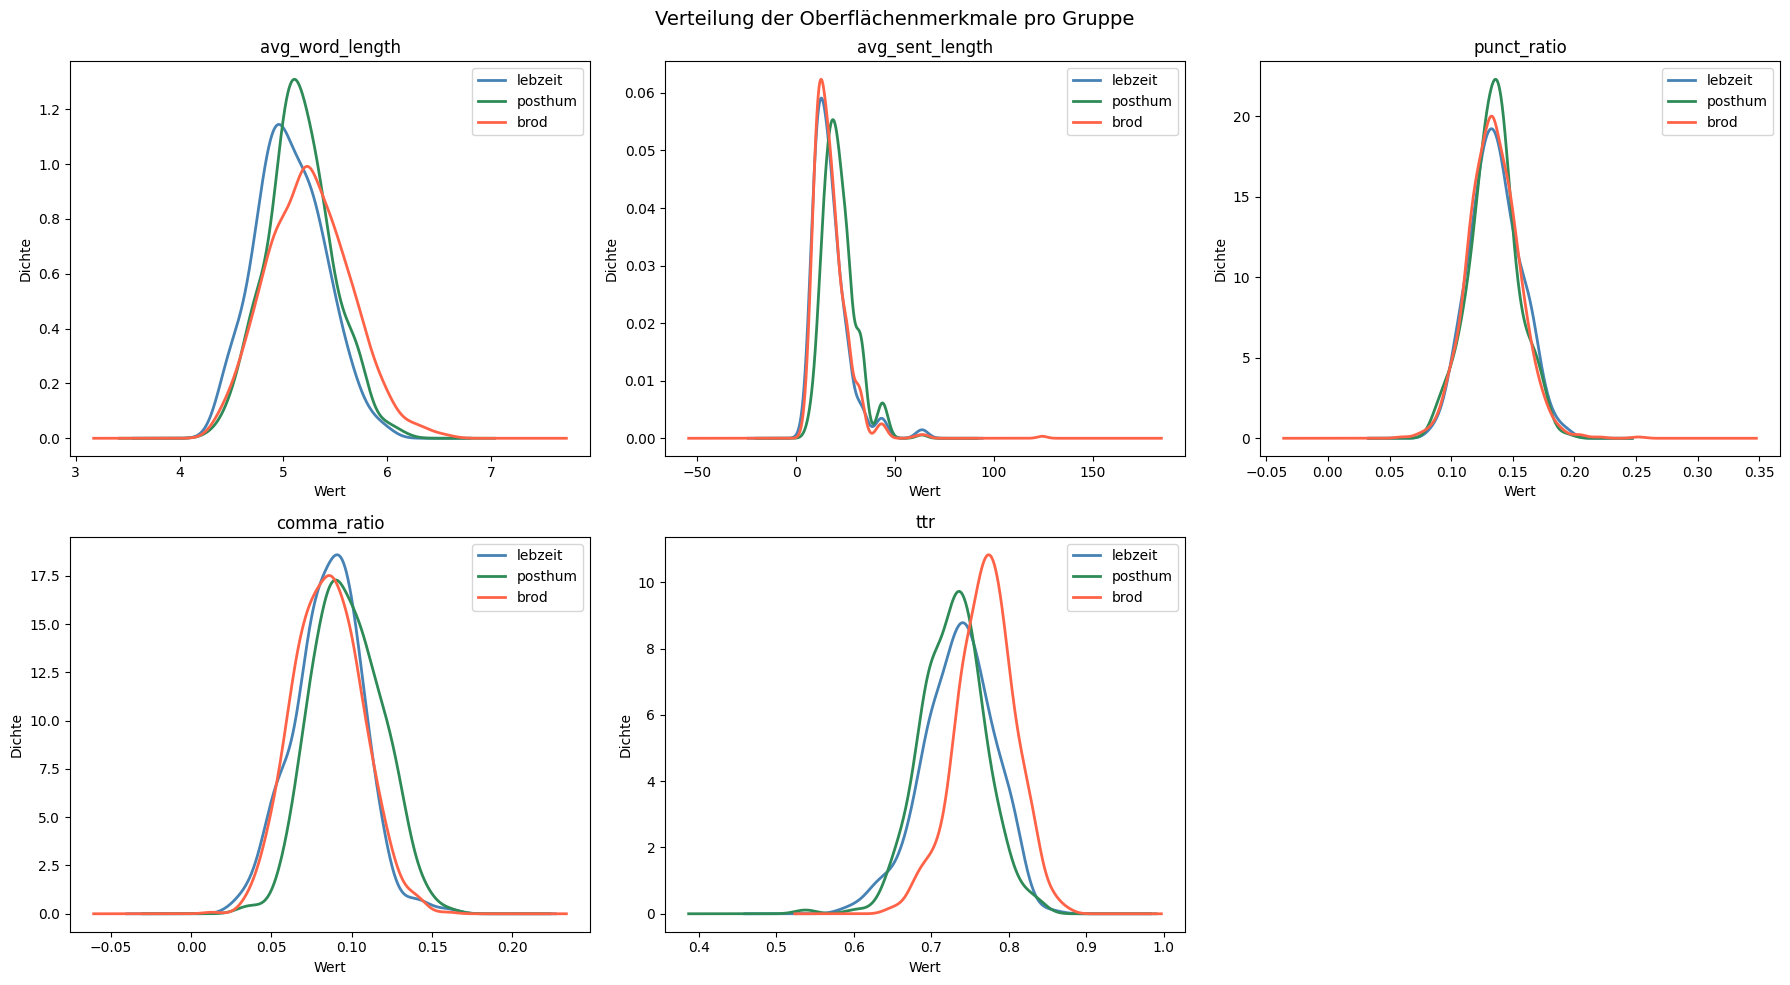

In [14]:
# ============================================================
# 7. VISUALISIERUNGEN
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = {"lebzeit": "steelblue", "posthum": "seagreen", "brod": "tomato"}
features_to_plot = ["avg_word_length", "avg_sent_length", "punct_ratio", "comma_ratio", "ttr"]
df_all = pd.concat([df_features, df_brod_features], ignore_index=True)

for i, feature in enumerate(features_to_plot):
    for label in ["lebzeit", "posthum", "brod"]:
        subset = df_all[df_all["label"] == label][feature]
        subset.plot.kde(ax=axes[i], linewidth=2,
                       label=label, color=colors[label])
    axes[i].set_title(feature)
    axes[i].legend()
    axes[i].set_xlabel("Wert")
    axes[i].set_ylabel("Dichte")

# Letzte leere Subplot ausblenden
axes[5].set_visible(False)

plt.suptitle("Verteilung der Oberflächenmerkmale pro Gruppe", fontsize=14)
plt.tight_layout()
plt.show()

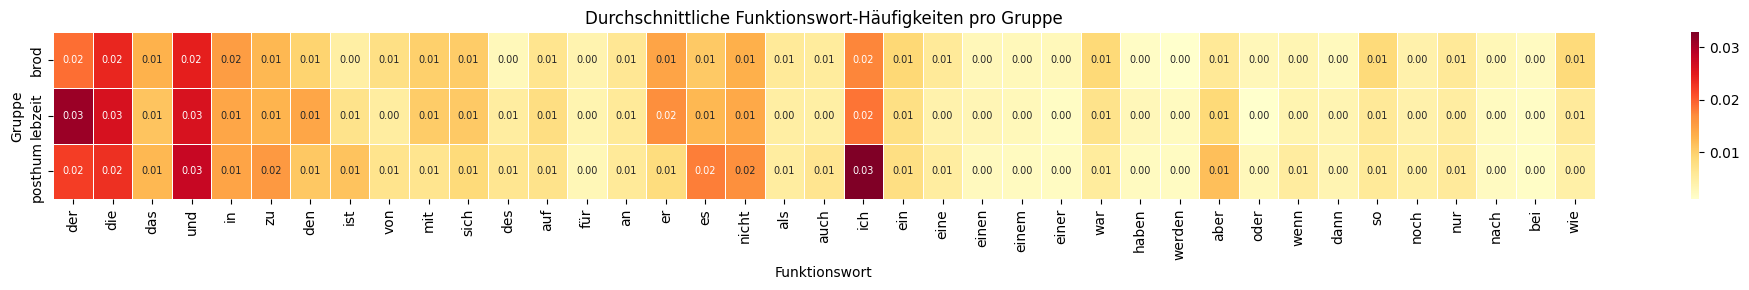

In [15]:
# Heatmap Funktionswörter
fw_cols = [col for col in core_cols if col.startswith("fw_")]

fw_means = df_all.groupby("label")[fw_cols].mean()
fw_means.columns = [col.replace("fw_", "") for col in fw_means.columns]

plt.figure(figsize=(20, 3))
sns.heatmap(fw_means, 
            annot=True, 
            fmt=".2f", 
            cmap="YlOrRd",
            linewidths=0.5,
            annot_kws={"size": 7})

plt.title("Durchschnittliche Funktionswort-Häufigkeiten pro Gruppe")
plt.xlabel("Funktionswort")
plt.ylabel("Gruppe")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 8. PCA
# ============================================================
from sklearn.decomposition import PCA

# Nur lebzeit und posthum für PCA
X_core = df_features[core_cols]
X_core_scaled = StandardScaler().fit_transform(X_core)
y = df_features["label"]

# Varianz prüfen
pca_test = PCA(n_components=10)
pca_test.fit(X_core_scaled)

print("Erklärte Varianz:")
cumvar = pca_test.explained_variance_ratio_.cumsum()
for i, var in enumerate(cumvar):
    print(f"PC{i+1}: {pca_test.explained_variance_ratio_[i]*100:.1f}% | kumulativ: {var*100:.1f}%")

Erklärte Varianz:
PC1: 10.6% | kumulativ: 10.6%
PC2: 5.7% | kumulativ: 16.3%
PC3: 4.1% | kumulativ: 20.5%
PC4: 3.7% | kumulativ: 24.2%
PC5: 3.5% | kumulativ: 27.6%
PC6: 3.0% | kumulativ: 30.7%
PC7: 2.8% | kumulativ: 33.5%
PC8: 2.6% | kumulativ: 36.0%
PC9: 2.5% | kumulativ: 38.6%
PC10: 2.4% | kumulativ: 41.0%


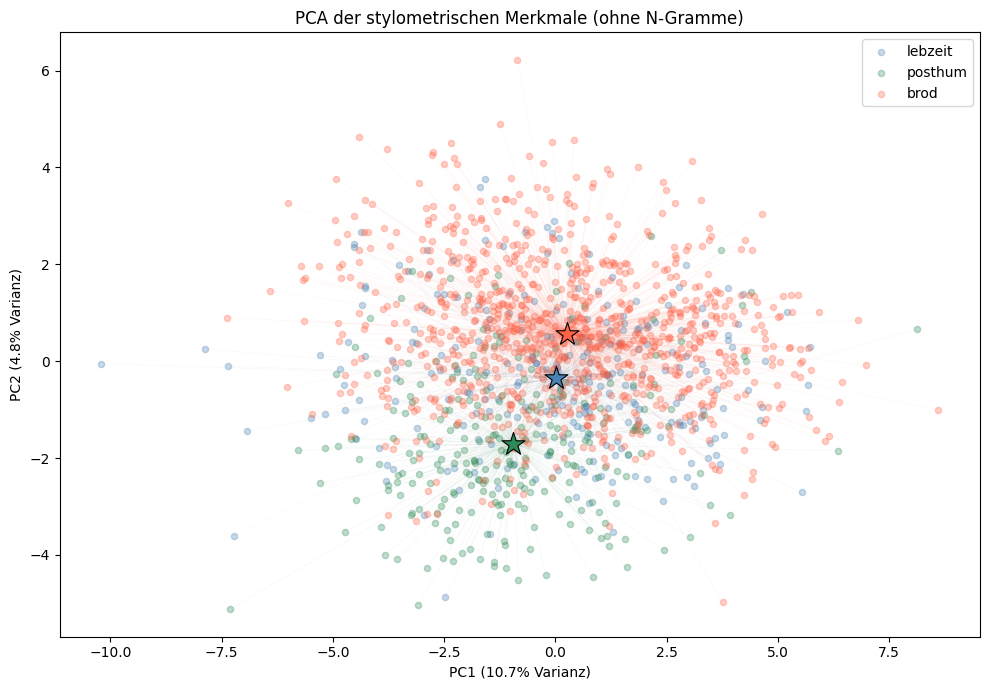

In [17]:
X_all = df_all[core_cols].fillna(0)
y_all = df_all["label"]
X_all_scaled = StandardScaler().fit_transform(X_all)

pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_all_scaled)

plt.figure(figsize=(10, 7))
colors = {"lebzeit": "steelblue", "posthum": "seagreen", "brod": "tomato"}

for label in ["lebzeit", "posthum", "brod"]:
    mask = y_all == label
    points = X_pca2[mask]
    
    # Punkte
    plt.scatter(points[:, 0], points[:, 1],
                c=colors[label], label=label, alpha=0.3, s=20)
    
    # Zentroid
    centroid = points.mean(axis=0)
    plt.scatter(centroid[0], centroid[1],
                c=colors[label], marker="*", s=300, 
                edgecolors="black", linewidths=0.8, zorder=5)
    
    # Linien vom Zentroid zu jedem Punkt
    for point in points:
        plt.plot([centroid[0], point[0]], [centroid[1], point[1]],
                 c=colors[label], alpha=0.05, linewidth=0.5)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.title("PCA der stylometrischen Merkmale (ohne N-Gramme)")
plt.legend()
plt.tight_layout()
plt.show()

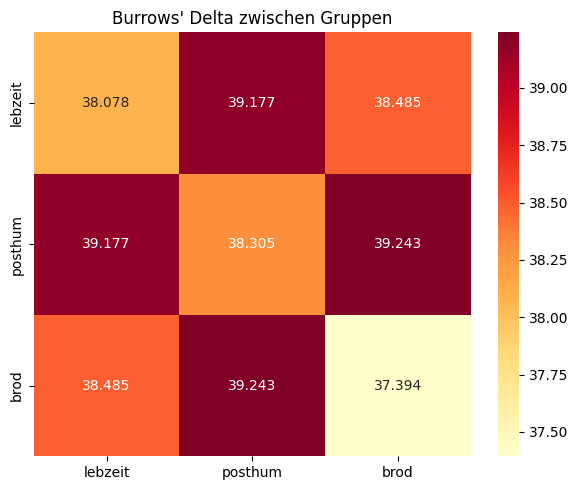


Burrows' Delta Distanzen:
lebzeit vs lebzeit: 38.078
lebzeit vs posthum: 39.177
lebzeit vs brod: 38.485
posthum vs lebzeit: 39.177
posthum vs posthum: 38.305
posthum vs brod: 39.243
brod vs lebzeit: 38.485
brod vs posthum: 39.243
brod vs brod: 37.394


In [18]:
# ============================================================
# 8. BURROWS' DELTA
# ============================================================

fw_cols = [col for col in core_cols if col.startswith("fw_")]
X_fw = df_all[fw_cols].values
X_fw_scaled = StandardScaler().fit_transform(X_fw)

# Burrows' Delta = Manhattan-Distanz auf z-skalierten Funktionswörtern
delta_matrix = pairwise_distances(X_fw_scaled, metric="manhattan")
groups = df_all["label"].values

# Durchschnittliche Distanz zwischen Gruppen
labels_order = ["lebzeit", "posthum", "brod"]
delta_group = np.zeros((3, 3))

for i, g1 in enumerate(labels_order):
    for j, g2 in enumerate(labels_order):
        mask1 = groups == g1
        mask2 = groups == g2
        delta_group[i, j] = delta_matrix[np.ix_(mask1, mask2)].mean()

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(delta_group,
            annot=True,
            fmt=".3f",
            xticklabels=labels_order,
            yticklabels=labels_order,
            cmap="YlOrRd")
plt.title("Burrows' Delta zwischen Gruppen")
plt.tight_layout()
plt.show()

# Werte ausgeben
print("\nBurrows' Delta Distanzen:")
for i, g1 in enumerate(labels_order):
    for j, g2 in enumerate(labels_order):
        print(f"{g1} vs {g2}: {delta_group[i,j]:.3f}")

label
brod       260
lebzeit    260
posthum    260
Name: count, dtype: int64


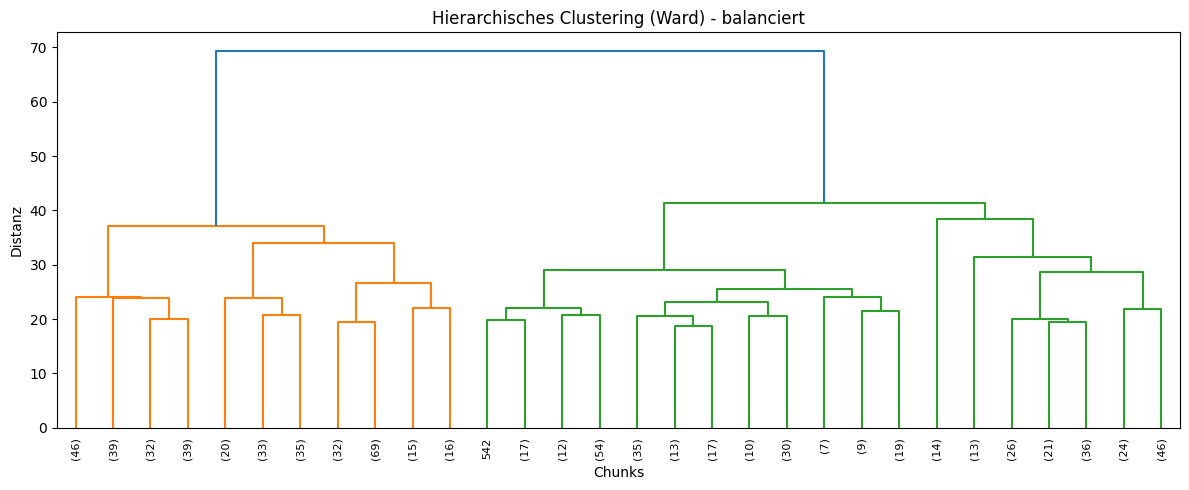

ARI hierarchisch: 0.055
Cluster         1    2   3
Echtes Label              
brod          145   42  73
lebzeit       150   52  58
posthum        81  130  49

ARI K-Means: 0.111
Cluster         0    1    2
Echtes Label               
brod          105  135   20
lebzeit        77  141   42
posthum        42   66  152


In [19]:
# ============================================================
# 9. CLUSTERANALYSE
# ============================================================
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

# Balanciertes df_all erstellen
min_size = df_all["label"].value_counts().min()
df_all_balanced = df_all.groupby("label").sample(min_size, random_state=42).reset_index(drop=True)

X_all_bal = df_all_balanced[core_cols].fillna(0)
y_all_bal = df_all_balanced["label"]
X_all_bal_scaled = StandardScaler().fit_transform(X_all_bal)

print(df_all_balanced["label"].value_counts())

# 1. Hierarchisches Clustering
plt.figure(figsize=(12, 5))
linked = linkage(X_all_bal_scaled, method="ward")
dendrogram(linked, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchisches Clustering (Ward) - balanciert")
plt.xlabel("Chunks")
plt.ylabel("Distanz")
plt.tight_layout()
plt.show()

# ARI hierarchisch
hier_labels = fcluster(linked, t=3, criterion="maxclust")
ari_hier = adjusted_rand_score(y_all_bal, hier_labels)
print(f"ARI hierarchisch: {ari_hier:.3f}")
print(pd.crosstab(y_all_bal, hier_labels, rownames=["Echtes Label"], colnames=["Cluster"]))

# 2. K-Means
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_all_bal_scaled)
ari_kmeans = adjusted_rand_score(y_all_bal, kmeans_labels)
print(f"\nARI K-Means: {ari_kmeans:.3f}")
print(pd.crosstab(y_all_bal, kmeans_labels, rownames=["Echtes Label"], colnames=["Cluster"]))

In [20]:
# ============================================================
# 10. RANDOM FOREST
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

pairs = [
    ("lebzeit_vs_posthum", "lebzeit", "posthum"),
    ("posthum_vs_brod", "posthum", "brod"),
]

results_rf = {}

for pair_name, label1, label2 in pairs:
    df_pair = df_all[df_all["label"].isin([label1, label2])].copy()
    
    min_size = df_pair["label"].value_counts().min()
    df_pair_bal = df_pair.groupby("label").sample(min_size, random_state=42)
    X_pair_bal = df_pair_bal[core_cols]
    y_pair_bal = df_pair_bal["label"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_pair_bal, y_pair_bal, test_size=0.3,
        random_state=42, stratify=y_pair_bal)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_test, y_pred)
    results_rf[pair_name] = acc
    
    print(f"\n{'='*50}")
    print(f"{pair_name}: Accuracy = {acc:.3f}")
    print(classification_report(y_test, y_pred))

print("\nZusammenfassung:")
for pair, acc in results_rf.items():
    print(f"{pair}: {acc:.3f}")


lebzeit_vs_posthum: Accuracy = 0.795
              precision    recall  f1-score   support

     lebzeit       0.77      0.85      0.80        78
     posthum       0.83      0.74      0.78        78

    accuracy                           0.79       156
   macro avg       0.80      0.79      0.79       156
weighted avg       0.80      0.79      0.79       156


posthum_vs_brod: Accuracy = 0.865
              precision    recall  f1-score   support

        brod       0.86      0.87      0.87        78
     posthum       0.87      0.86      0.86        78

    accuracy                           0.87       156
   macro avg       0.87      0.87      0.87       156
weighted avg       0.87      0.87      0.87       156


Zusammenfassung:
lebzeit_vs_posthum: 0.795
posthum_vs_brod: 0.865
